In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/Skripsi/dataset/'

def load_dataset(folder, size=(224, 224)):
    images = []
    for files in os.listdir(folder):
        img_path = os.path.join(folder, files)
        img = cv2.imread(img_path)
        if img is not None:
            img_resized = cv2.resize(img, size)
            images.append((files, img_resized))
    return images


image_datasets = {
    'healthy_kernel': load_dataset(os.path.join(base_dir, 'healthy_kernel')),
    'green_immature': load_dataset(os.path.join(base_dir, 'green_immature')),
    'shrunken_broken': load_dataset(os.path.join(base_dir, 'shrunken_broken')),
    'insect_chewed': load_dataset(os.path.join(base_dir, 'insect_chewed'))
}

for label, images in image_datasets.items():
    print(f'{label}: {len(images)} images loaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
healthy_kernel: 500 images loaded.
green_immature: 500 images loaded.
shrunken_broken: 500 images loaded.
insect_chewed: 500 images loaded.


In [5]:
def extract_glcm_features(image):
    """Extract GLCM texture features from image"""
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')
    dissimilarity = graycoprops(glcm, 'dissimilarity')
    homogeneity = graycoprops(glcm, 'homogeneity')
    energy = graycoprops(glcm, 'energy')
    correlation = graycoprops(glcm, 'correlation')

    features = [
        contrast[0, 0],
        dissimilarity[0, 0],
        homogeneity[0, 0],
        energy[0, 0],
        correlation[0, 0],
    ]

    return features

In [6]:
def extract_rgb_features(image):
    """Extract RGB color features - focusing on Green channel"""
    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Extract green channel
    green_channel = image[:, :, 1]

    # Calculate mean and standard deviation of the green channel
    mean_green = np.mean(green_channel)
    std_green = np.std(green_channel)

    features_rgb = [mean_green, std_green]

    return features_rgb

In [7]:
def extract_hsv_features(image):
    """Extract HSV color features - focusing on Value channel"""
    # Convert BGR to HSV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Extract V (Value) channel
    v_channel = image[:, :, 2]
    # Calculate mean and standard deviation of the V channel
    mean_v = np.mean(v_channel)
    std_v = np.std(v_channel)

    features_hsv = [mean_v, std_v]

    return features_hsv

In [8]:
def extract_all_features(image):
    """Extract all features from a single image"""
    glcm_features = extract_glcm_features(image)
    rgb_features = extract_rgb_features(image)
    hsv_features = extract_hsv_features(image)

    # Combine all features
    all_features = glcm_features + rgb_features + hsv_features
    return all_features
print('Feature extraction functions ready!')

Feature extraction functions ready!


In [9]:
# Extract features for all images
features, labels = [], []

for label, images in image_datasets.items():
    print(f"Processing {label}...")
    for i, (filename, image_data) in enumerate(images):
        try:
            extracted_features = extract_all_features(image_data)
            features.append(extracted_features)
            labels.append(label)

            # Progress indicator
            if (i + 1) % 100 == 0:
                print(f"  Processed {i + 1}/{len(images)} images")

        except Exception as e:
            print(f"  Error processing image {filename}: {e}")
            continue

print(f'\nExtracted features for {len(features)} images.')

Processing healthy_kernel...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing green_immature...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing shrunken_broken...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing insect_chewed...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images

Extracted features for 2000 images.


In [10]:
# Define column names
glcm_columns = [
    'contrast_0',
    'dissimilarity_0',
    'homogeneity_0',
    'energy_0',
    'correlation_0',
]

rgb_columns = [
    'mean_g', 'std_g'
]

hsv_columns = [
    'mean_v', 'std_v'
]

# Combine column names
columns = glcm_columns + rgb_columns + hsv_columns

# Create DataFrame
df = pd.DataFrame(features, columns=columns)
df['Label'] = labels

print("DataFrame Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

DataFrame Info:
Shape: (2000, 10)
Columns: ['contrast_0', 'dissimilarity_0', 'homogeneity_0', 'energy_0', 'correlation_0', 'mean_g', 'std_g', 'mean_v', 'std_v', 'Label']

First 5 rows:
   contrast_0  dissimilarity_0  homogeneity_0  energy_0  correlation_0  \
0   32.882968         0.733224       0.942904  0.924877       0.992032   
1   42.579596         1.290879       0.877807  0.848025       0.992199   
2   95.074311         2.368794       0.845789  0.822902       0.984437   
3  113.955197         2.778387       0.840879  0.817161       0.982383   
4   37.005766         0.980501       0.912103  0.885693       0.989380   

      mean_g      std_g     mean_v      std_v           Label  
0  11.298728  44.503811  13.414441  52.647710  healthy_kernel  
1  20.354472  51.169616  25.518335  63.717388  healthy_kernel  
2  22.959522  54.423133  28.697186  66.885373  healthy_kernel  
3  24.103077  56.121553  29.927954  68.543970  healthy_kernel  
4  12.637476  40.082063  16.067323  50.503787  hea

In [11]:
# Check for any NaN values
print(f"NaN values per column:")
print(df.isnull().sum())

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Basic statistics
print(f"\nBasic statistics for requested features:")
requested_features = ['mean_g', 'std_g', 'mean_v', 'std_v']
print(df[requested_features].describe())

# Save to files
df.to_excel('features_corrected.xlsx', index=False)
df.to_csv('features_corrected.csv', index=False)
print("\nFiles saved: features_corrected.xlsx and features_corrected.csv")

NaN values per column:
contrast_0         0
dissimilarity_0    0
homogeneity_0      0
energy_0           0
correlation_0      0
mean_g             0
std_g              0
mean_v             0
std_v              0
Label              0
dtype: int64

Data types:
contrast_0         float64
dissimilarity_0    float64
homogeneity_0      float64
energy_0           float64
correlation_0      float64
mean_g             float64
std_g              float64
mean_v             float64
std_v              float64
Label               object
dtype: object

Basic statistics for requested features:
            mean_g        std_g       mean_v        std_v
count  2000.000000  2000.000000  2000.000000  2000.000000
mean     39.917823    68.053610    46.934657    79.064427
std      17.641847    14.952231    20.283827    16.322377
min       8.138552    35.112021    10.016183    40.659336
25%      25.817876    56.762570    30.515092    66.208453
50%      40.709672    68.599517    48.496283    79.642755
75%      

In [12]:
# Label distribution
print("Label distribution:")
print(df['Label'].value_counts())

Label distribution:
Label
healthy_kernel     500
green_immature     500
shrunken_broken    500
insect_chewed      500
Name: count, dtype: int64


In [13]:
# Separate features and labels
X = df.drop('Label', axis=1)
y = df['Label']

# Check for any remaining issues
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Label distribution:")
print(y.value_counts())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Feature matrix shape: (2000, 9)
Labels shape: (2000,)
Label distribution:
Label
healthy_kernel     500
green_immature     500
shrunken_broken    500
insect_chewed      500
Name: count, dtype: int64

Training set size: 1600
Test set size: 400


In [14]:
# ================================================
# FIX 1: Feature Scaling (StandardScaler)
# SVM sangat sensitif terhadap skala fitur.
# Fitur GLCM (contrast bisa ratusan) vs homogeneity (0-1)
# harus dinormalisasi agar SVM bekerja optimal.
# PENTING: fit hanya pada data train, transform pada keduanya.
# ================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform saja, bukan fit_transform!

print("Feature scaling applied (StandardScaler)")
print(f"Mean of scaled training features (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std of scaled training features (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Feature scaling applied (StandardScaler)
Mean of scaled training features (should be ~0): [-0. -0. -0. -0.  0. -0.  0.  0. -0.]
Std of scaled training features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
%%time
print("Training SVM Classifier... with LinearSVC() function")
print("="*50)

# Train SVM model dengan random_state untuk reproducibility
clf_LinearSVC = LinearSVC(random_state=42, max_iter=2000)
clf_LinearSVC.fit(X_train_scaled, y_train)

print("\u2713 SVM model trained successfully!")

Training SVM Classifier... with LinearSVC() function
✓ SVM model trained successfully!
CPU times: user 22.9 ms, sys: 0 ns, total: 22.9 ms
Wall time: 34.5 ms


Accuracy: 0.8875

Detailed Classification Report with LinearSVC:
                 precision    recall  f1-score   support

 green_immature       0.95      0.97      0.96       100
 healthy_kernel       0.90      0.93      0.92       100
  insect_chewed       0.85      0.89      0.87       100
shrunken_broken       0.84      0.76      0.80       100

       accuracy                           0.89       400
      macro avg       0.89      0.89      0.89       400
   weighted avg       0.89      0.89      0.89       400



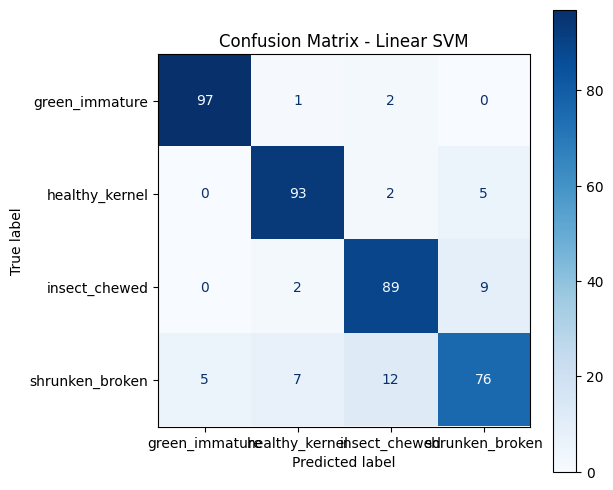

In [16]:
# Make predictions
y_pred = clf_LinearSVC.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report with LinearSVC:")
print("="*60)
print(classification_report(y_test, y_pred))
print("="*60)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_estimator(clf_LinearSVC, X_test_scaled, y_test, cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [17]:
# ================================================
# FIX 3: Cross-Validation (5-Fold)
# Lebih robust daripada single train-test split.
# Memberikan estimasi performa yang lebih reliable.
# ================================================
from sklearn.pipeline import Pipeline

# Buat pipeline agar scaling dilakukan per-fold secara benar
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=42, max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print("Cross-Validation Results (5-Fold):")
print("="*40)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")
print(f"95% CI        : [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]")

Cross-Validation Results (5-Fold):
  Fold 1: 0.8900
  Fold 2: 0.8450
  Fold 3: 0.8825
  Fold 4: 0.8950
  Fold 5: 0.8750

Mean Accuracy : 0.8775
Std Deviation : 0.0176
95% CI        : [0.8423, 0.9127]


FEATURE IMPORTANCE ANALYSIS

Permutation Importance (lebih akurat untuk multi-class):
        Feature  Importance_Mean  Importance_Std
  correlation_0          0.07075        0.009357
     contrast_0          0.12725        0.010980
dissimilarity_0          0.17850        0.018035
       energy_0          0.25050        0.029618
         mean_g          0.35225        0.028624
         mean_v          0.36175        0.016319
  homogeneity_0          0.42800        0.026096
          std_v          0.43500        0.014577
          std_g          0.47775        0.026913


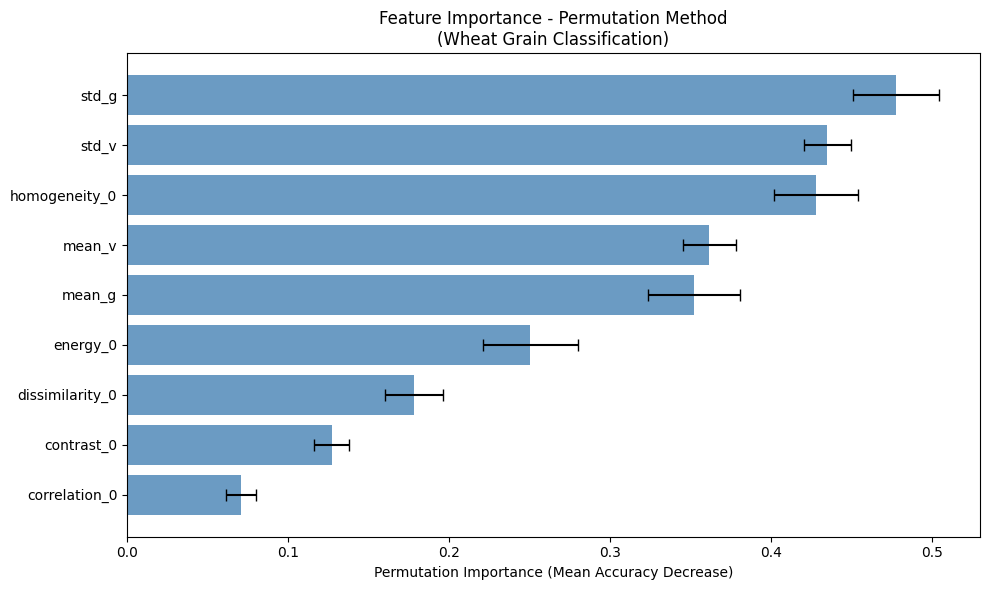

In [18]:
# ================================================
# FIX 4: Feature Importance yang lebih akurat
# menggunakan Permutation Importance
# Lebih reliable untuk multi-class dibanding coef_
# ================================================
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Permutation Importance - lebih akurat untuk multi-class
perm_result = permutation_importance(
    clf_LinearSVC, X_test_scaled, y_test,
    n_repeats=10, random_state=42
)

feature_names = X.columns.tolist()
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=True)

print("\nPermutation Importance (lebih akurat untuk multi-class):")
print(perm_importance_df.to_string(index=False))

# Visualisasi Permutation Importance
plt.figure(figsize=(10, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df['Importance_Mean'],
    xerr=perm_importance_df['Importance_Std'],
    color='steelblue', alpha=0.8, capsize=4
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df['Feature'])
plt.xlabel('Permutation Importance (Mean Accuracy Decrease)')
plt.title('Feature Importance - Permutation Method\n(Wheat Grain Classification)')
plt.tight_layout()
plt.show()


Coefficient-based Importance (referensi):
(rata-rata absolut koefisien per kelas)
        Feature  Importance
  correlation_0    0.017676
     contrast_0    0.037524
dissimilarity_0    0.044407
       energy_0    0.087382
  homogeneity_0    0.108225
         mean_g    0.132654
         mean_v    0.139688
          std_v    0.215561
          std_g    0.216882


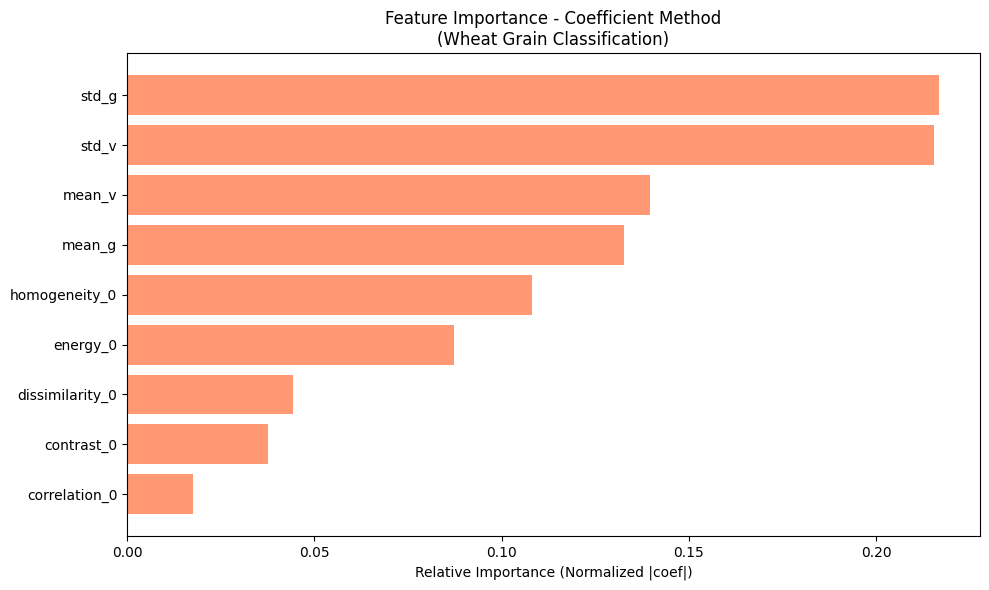

In [19]:
# Sebagai perbandingan, tampilkan juga coef_-based importance
print("\nCoefficient-based Importance (referensi):")
print("(rata-rata absolut koefisien per kelas)")
print("="*50)

coef_importance = np.abs(clf_LinearSVC.coef_).mean(axis=0)
coef_importance = coef_importance / coef_importance.sum()

coef_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coef_importance
}).sort_values('Importance', ascending=True)

print(coef_importance_df.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 6))
plt.barh(
    range(len(coef_importance_df)),
    coef_importance_df['Importance'],
    color='coral', alpha=0.8
)
plt.yticks(range(len(coef_importance_df)), coef_importance_df['Feature'])
plt.xlabel('Relative Importance (Normalized |coef|)')
plt.title('Feature Importance - Coefficient Method\n(Wheat Grain Classification)')
plt.tight_layout()
plt.show()